<a href="https://colab.research.google.com/github/mansorabi324/7-Abiyyu-Derryl/blob/main/Derryll_EDA_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from jcopml.plot import plot_correlation_matrix

from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


## Analisis Kategorik


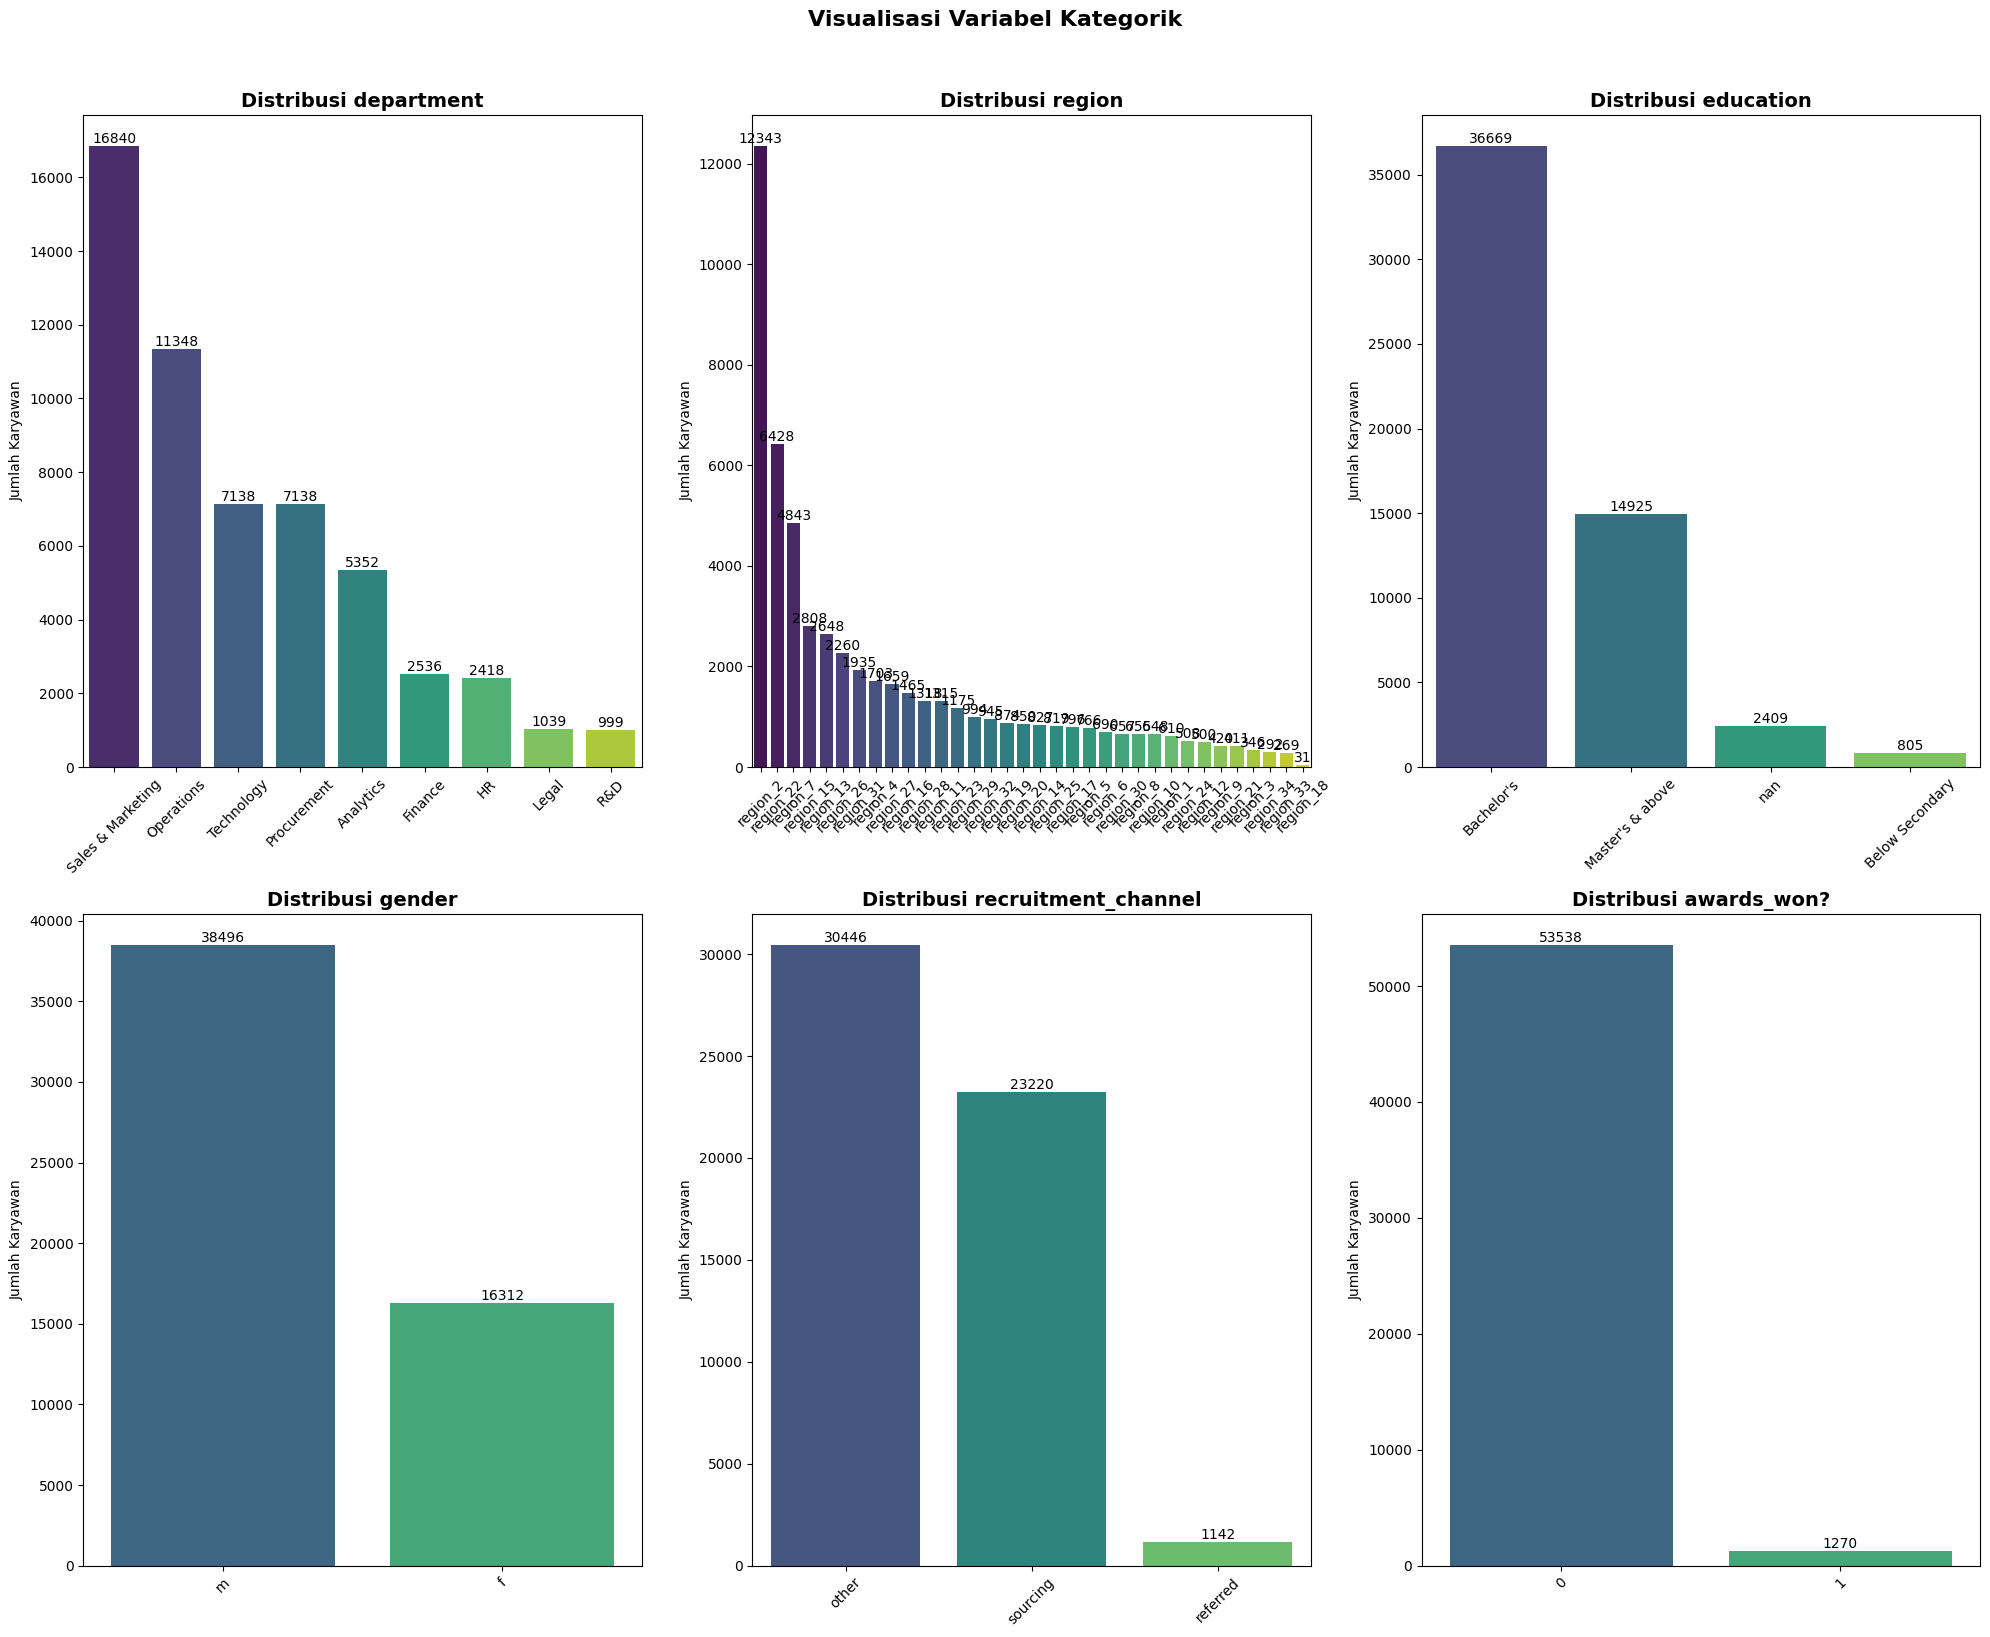

In [ ]:
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel', 'awards_won?']

fig, axes = plt.subplots(2, 3, figsize=(20, 16))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col] = df[col].astype(str)

    value_counts = df[col].value_counts().sort_values(ascending=False)

    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        hue=value_counts.index,
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 0.1, str(v), ha='center', va='bottom')

    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Distribusi {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah Karyawan')

plt.suptitle('Visualisasi Variabel Kategorik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Korelasi

In [ ]:
categorical_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel',
]

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['is_promoted'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"{col}")
    print(f"Chi2 value : {chi2:.4f}")
    print(f"P-value    : {p:.4f}")
    print("-"*40)

department
Chi2 value : 151.4264
P-value    : 0.0000
----------------------------------------
region
Chi2 value : 475.6402
P-value    : 0.0000
----------------------------------------
education
Chi2 value : 75.8734
P-value    : 0.0000
----------------------------------------
gender
Chi2 value : 6.6773
P-value    : 0.0098
----------------------------------------
recruitment_channel
Chi2 value : 19.2363
P-value    : 0.0001
----------------------------------------


In [ ]:
results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df['is_promoted'])
    chi2, p, dof, expected = chi2_contingency(table)

    results.append([col, chi2, p])

chi_square_result = pd.DataFrame(results, columns=['Feature','Chi2','p_value'])

chi_square_result

,Feature,Chi2,p_value
0,department,151.426355,9.882497e-29
1,region,475.640238,7.275378e-80
2,education,75.873410,2.354496e-16
3,gender,6.677255,9.765092e-03
4,recruitment_channel,19.236335,6.650938e-05


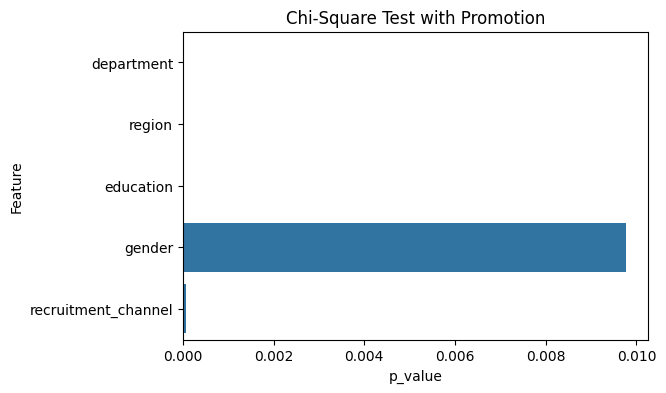

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='p_value',
    y='Feature',
    data=chi_square_result
)

plt.title("Chi-Square Test with Promotion")
plt.show()

In [ ]:
plot_correlation_matrix(df, 'is_promoted', numeric_col=['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'avg_training_score'])

interactive(children=(ToggleButtons(description='method', options=('spearman', 'kendall', 'pearson', 'pearson_…

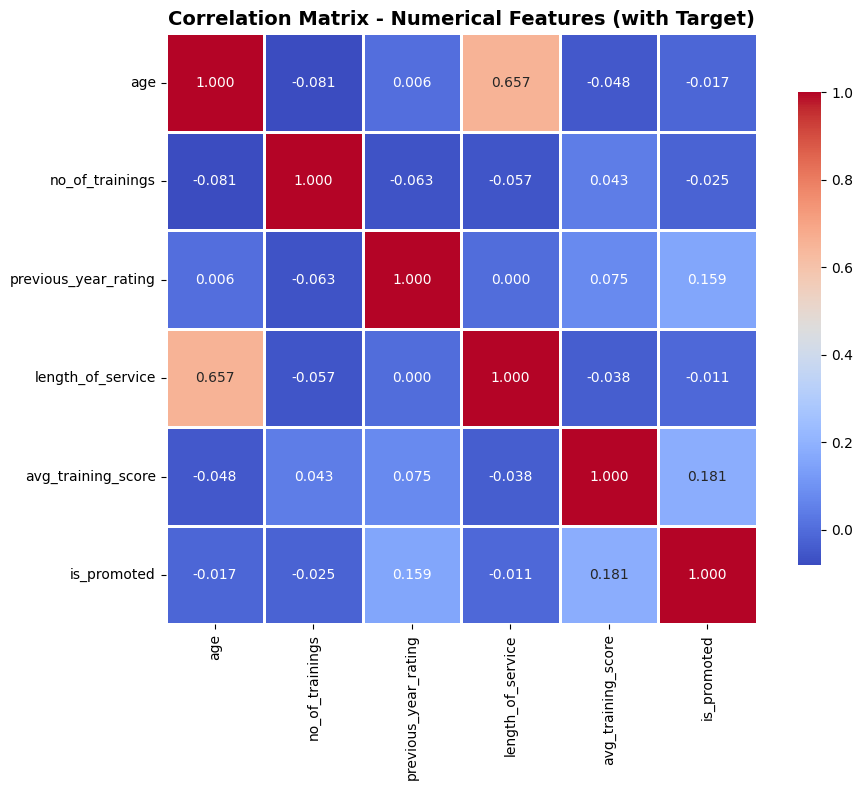

In [ ]:
cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score",
    "is_promoted"
]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f",
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix - Numerical Features (with Target)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

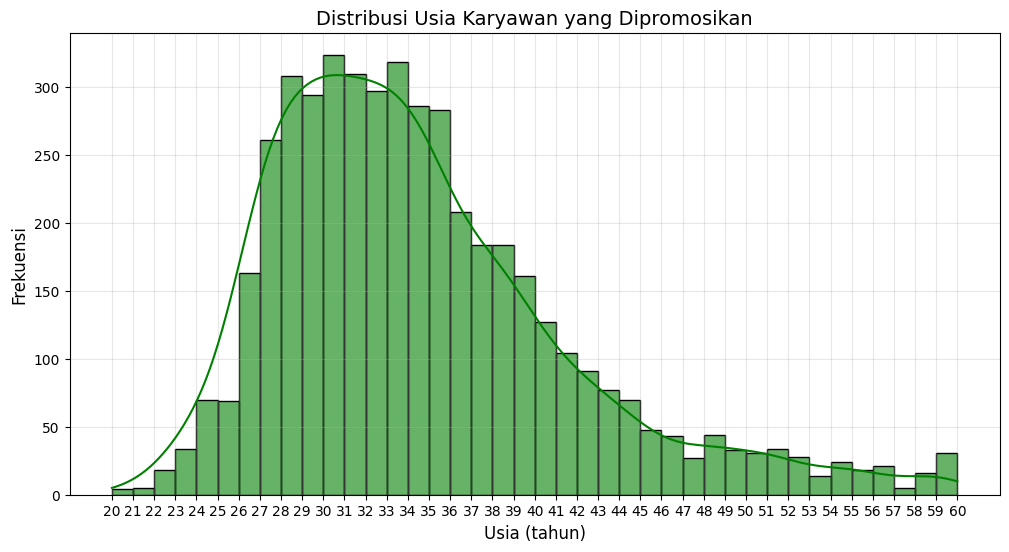

In [ ]:
# Filter data yang dipromosi aja
df_promoted = df[df['is_promoted'] == 1]

plt.figure(figsize=(12, 6))
sns.histplot(data=df_promoted, x='age', bins=40,
             alpha=0.6, kde=True, color='green')
plt.title('Distribusi Usia Karyawan yang Dipromosikan', fontsize=14)
plt.xlabel('Usia (tahun)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Set ticks umur dari 20 sampai 60 dengan step 1
plt.xticks(range(20, 61, 1))

plt.grid(True, alpha=0.3)
plt.show()

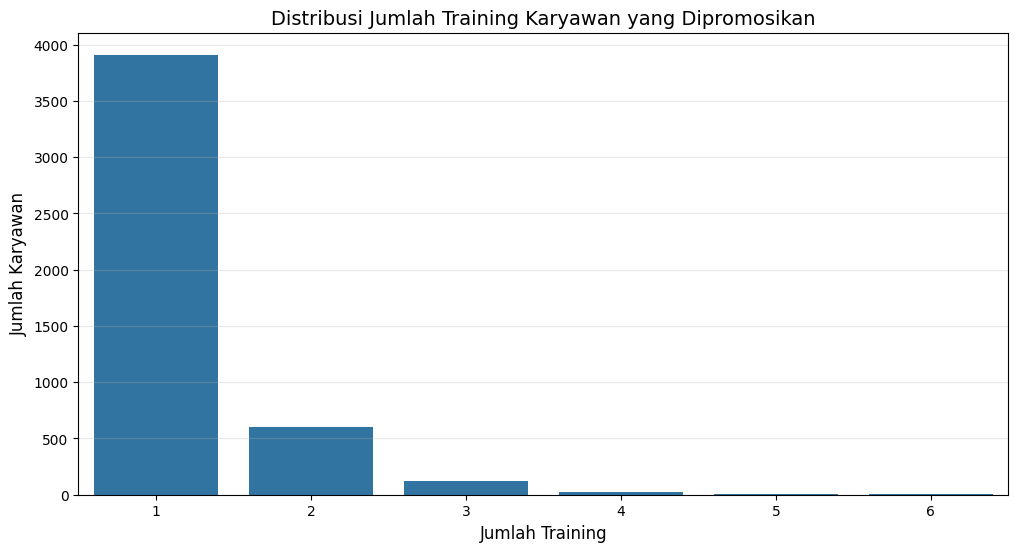

In [ ]:
df_promoted = df[df['is_promoted'] == 1]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_promoted, x='no_of_trainings')
plt.title('Distribusi Jumlah Training Karyawan yang Dipromosikan', fontsize=14)
plt.xlabel('Jumlah Training', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

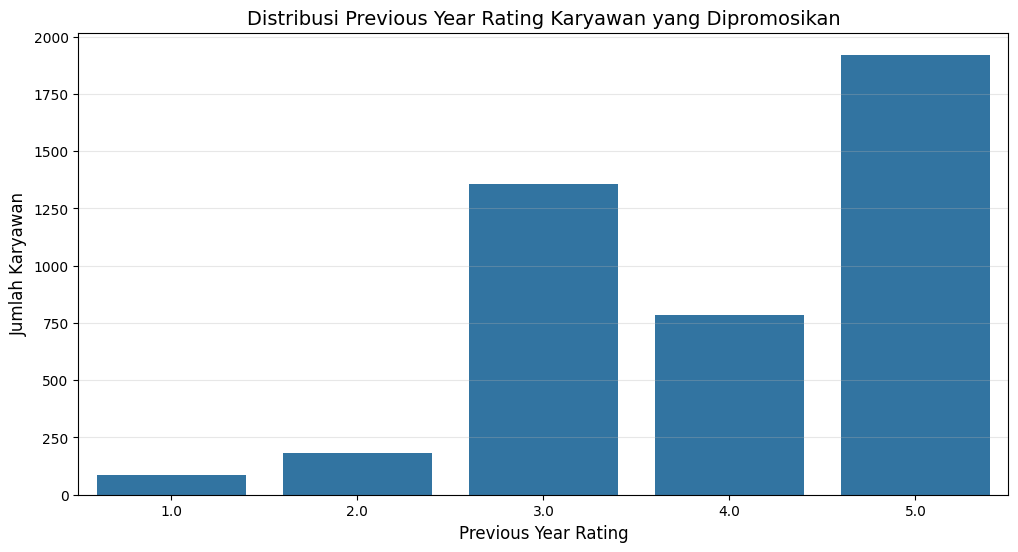

In [ ]:
# Filter data yang dipromosi aja
df_promoted = df[df['is_promoted'] == 1]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_promoted, x='previous_year_rating')
plt.title('Distribusi Previous Year Rating Karyawan yang Dipromosikan', fontsize=14)
plt.xlabel('Previous Year Rating', fontsize=12)
plt.ylabel('Jumlah Karyawan', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

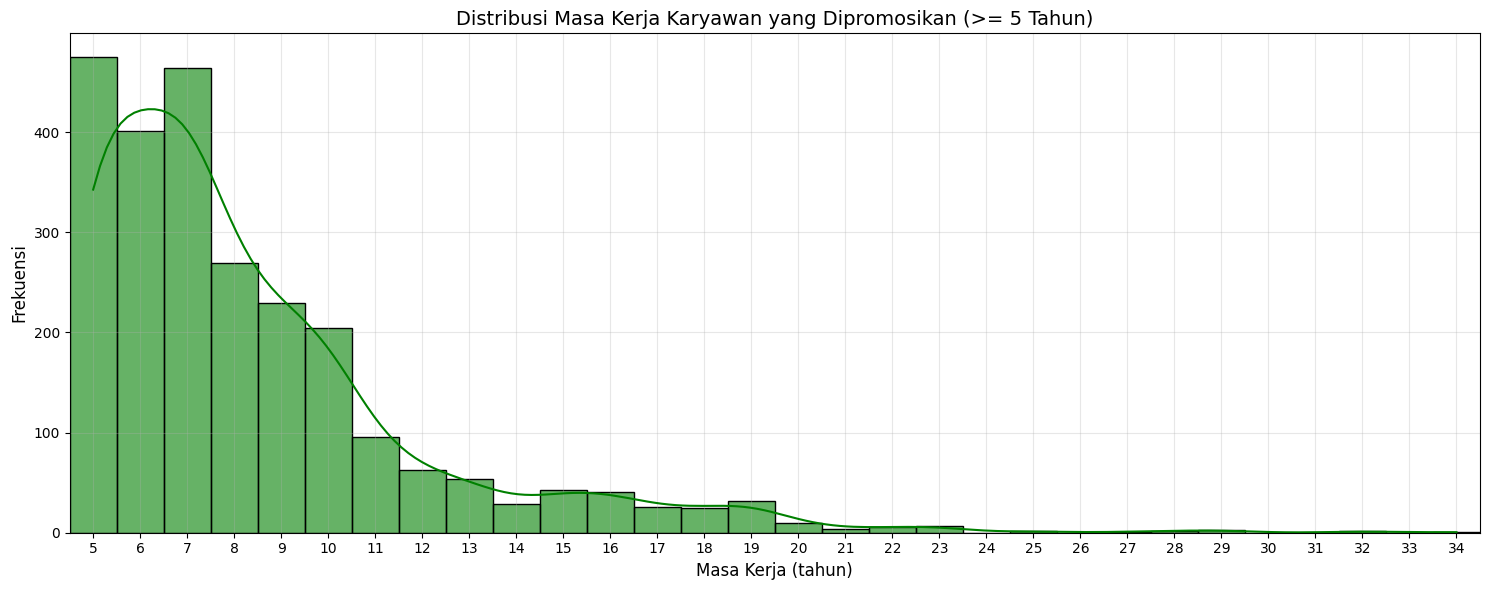

In [ ]:
# Filter data yang dipromosi dan masa kerja >= 5 tahun
df_promoted_filtered = df[(df['is_promoted'] == 1) & (df['length_of_service'] >= 5)]

plt.figure(figsize=(15, 6))
sns.histplot(data=df_promoted_filtered, x='length_of_service', bins=30,
             alpha=0.6, kde=True, color='green', discrete=True)
plt.title('Distribusi Masa Kerja Karyawan yang Dipromosikan (>= 5 Tahun)', fontsize=14)
plt.xlabel('Masa Kerja (tahun)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Set ticks dari 5 sampai max
min_filtered = int(df_promoted_filtered['length_of_service'].min())
max_filtered = int(df_promoted_filtered['length_of_service'].max())
plt.xticks(range(min_filtered, max_filtered+1, 1))

# Set xlim mulai dari 5
plt.xlim(4.5, max_filtered+0.5)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

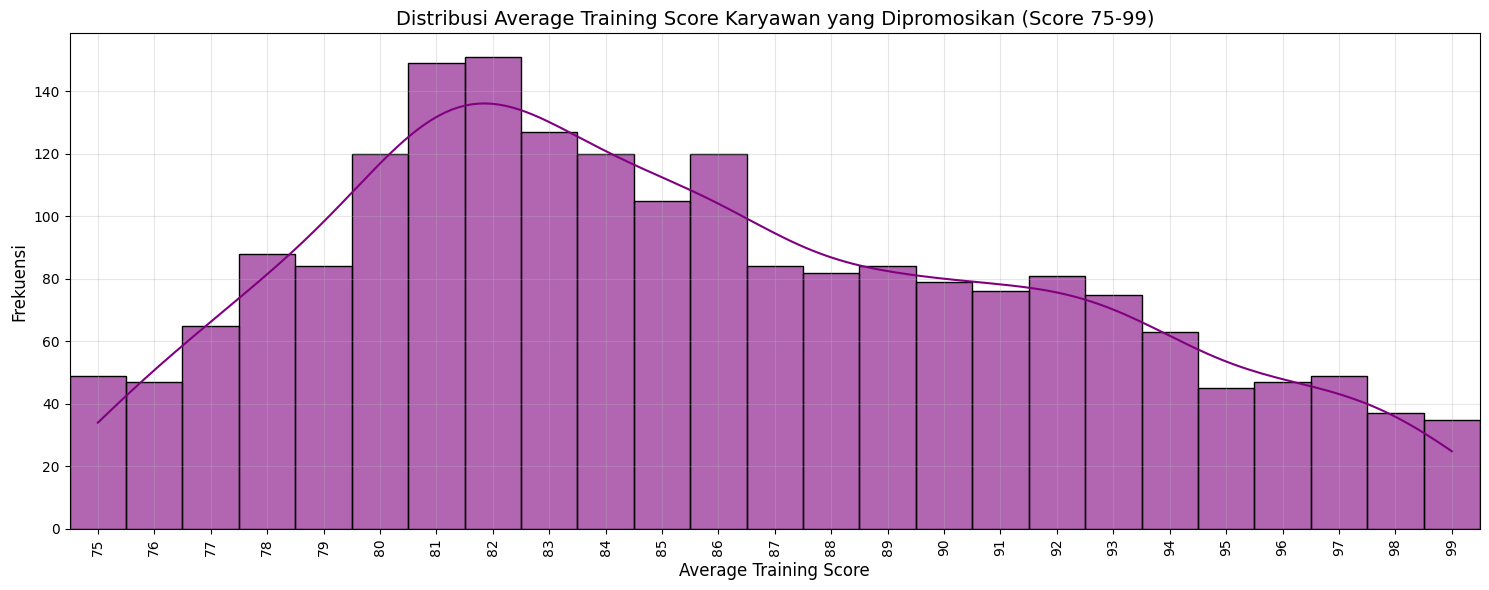

In [ ]:
# Filter data yang dipromosi dan score antara 75-99
df_promoted_filtered = df[(df['is_promoted'] == 1) & (df['avg_training_score'] >= 75) & (df['avg_training_score'] <= 99)]

plt.figure(figsize=(15, 6))
sns.histplot(data=df_promoted_filtered, x='avg_training_score', bins=25,
             alpha=0.6, kde=True, color='purple', discrete=True)
plt.title('Distribusi Average Training Score Karyawan yang Dipromosikan (Score 75-99)', fontsize=14)
plt.xlabel('Average Training Score', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Set ticks dari 75 sampai 99
plt.xticks(range(75, 100, 1), rotation=90)

# Set xlim biar fokus ke 75-99
plt.xlim(74.5, 99.5)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

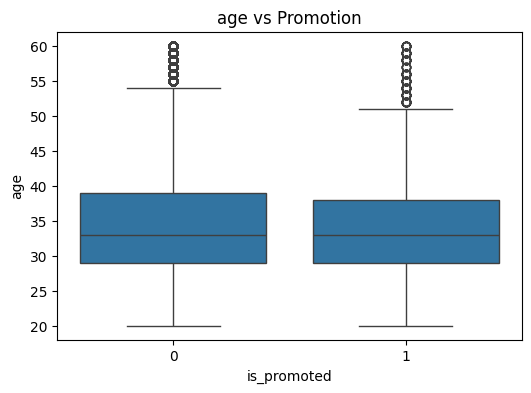

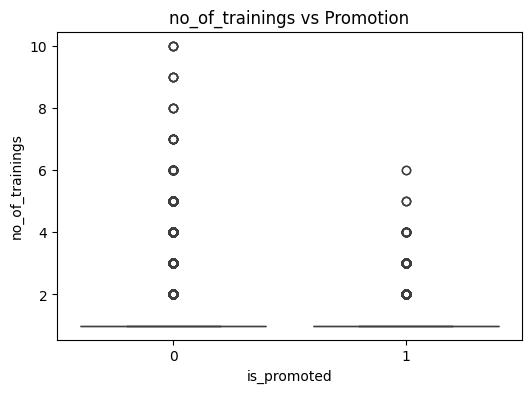

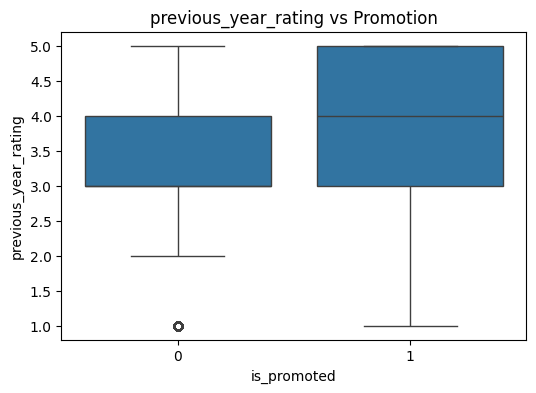

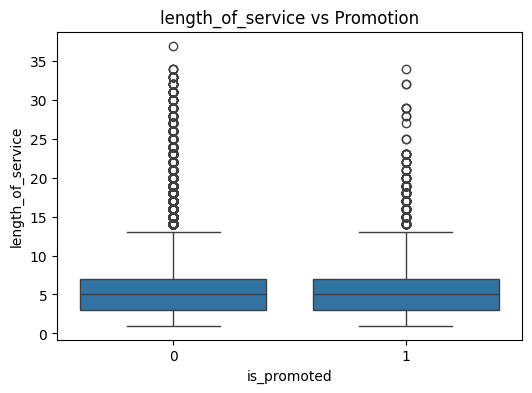

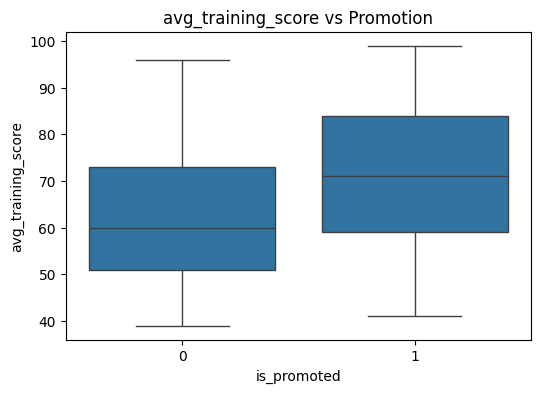

In [ ]:
num_cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score"
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="is_promoted", y=col, data=df)
    plt.title(f"{col} vs Promotion")
    plt.show()

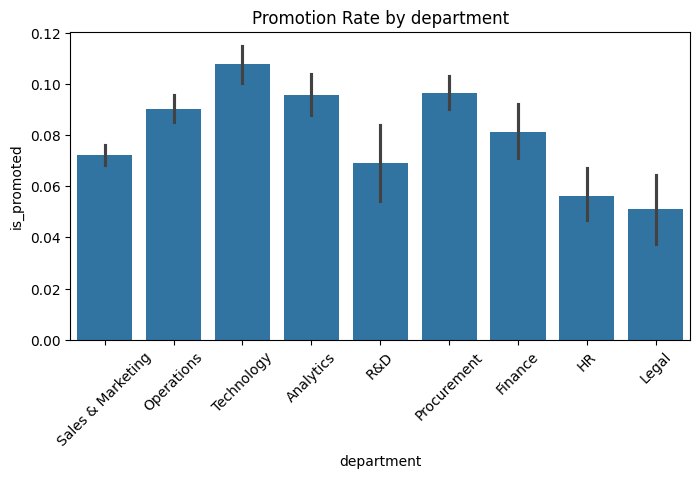

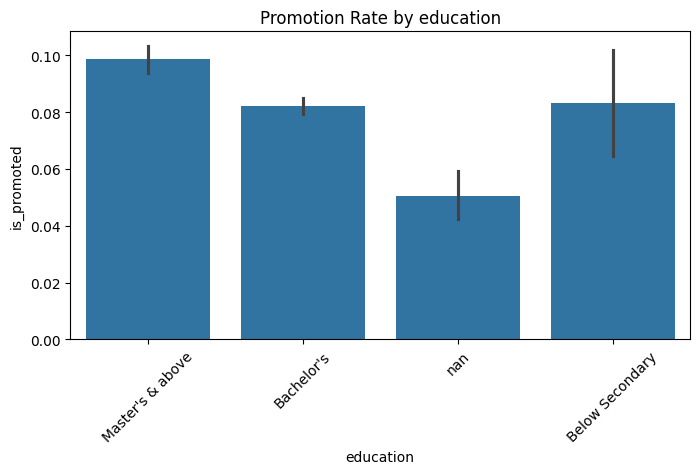

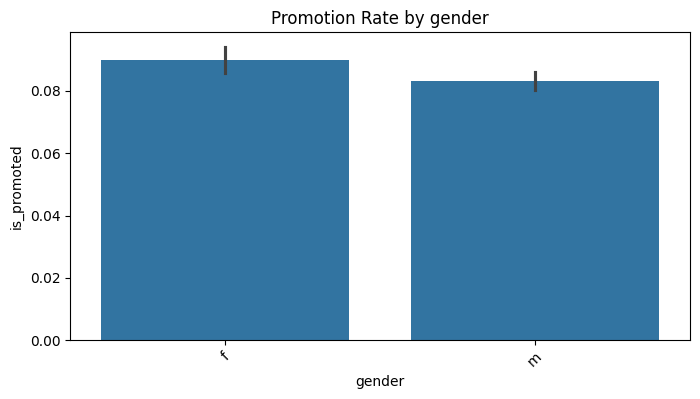

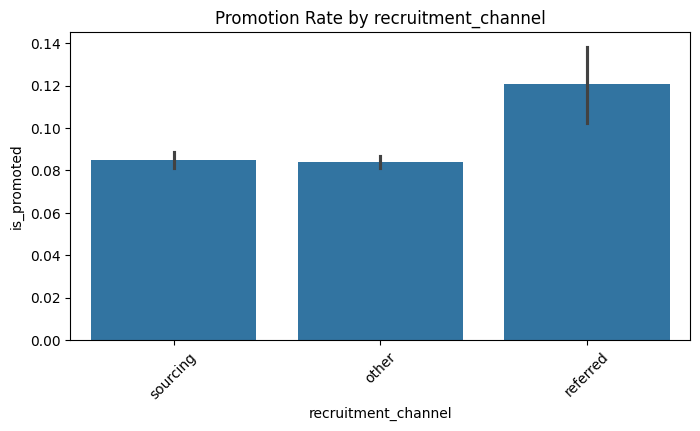

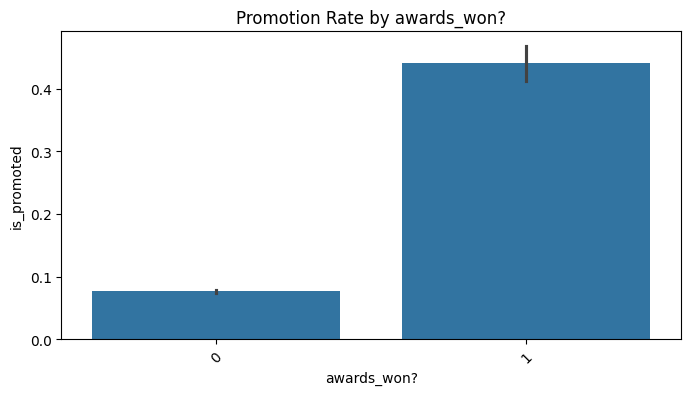

In [ ]:
cat_cols = [
    "department",
    "education",
    "gender",
    "recruitment_channel",
    "awards_won?"
]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y="is_promoted", data=df)
    plt.title(f"Promotion Rate by {col}")
    plt.xticks(rotation=45)
    plt.show()